In [84]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.timeseries import LombScargle
import pandas as pd
import scipy.io as sp
from spleaf import cov, term
from scipy.optimize import fmin_l_bfgs_b
import re
import emcee

# Read data from simulation and format for S+Leaf

In [ ]:
realis = 2
use_file = f"../../../non_stationary_gp/nskernel/data/serie_res_bt_G2_1000_4m_NOISE0.09_OGS_MAG_M1_real{realis}.sav"
data = sp.readsav(use_file)

arr_len = len(data['tt'])
tt = data['tt']
rv = data['rv']
rhk = data['ca']
erv = np.zeros(len(rhk))+0.09
rhk_err = np.zeros(len(rhk))+5e-4

rv_mean = np.mean(rv)
rv_std  = np.std(rv)
rv_norm = (rv - rv_mean) / rv_std

# RHK normalization
rhk_mean = np.mean(rhk)
rhk_std  = np.std(rhk)
rhk_norm = (rhk - rhk_mean) / rhk_std

# ERROR normalization using SAME scaling as parent data
erv_norm     = erv / rv_std
rhk_err_norm = rhk_err / rhk_std

# erv_norm *=50
# rhk_err_norm *=50

T = [tt,tt]
Y = [rv_norm,rhk_norm]
Yerr = [erv_norm,rhk_err_norm]

t_full, y_full, yerr_full, series_index = cov.merge_series(T,Y,Yerr)

# Define kernels (rotation and cycle) and negative log-likelihood function

In [86]:

stds = [np.std(y) for y in Y]

sig0 = np.var(y_full)          
period0 = 21.3 
Q0 = 2.0
period1 = 2000.0
Q1 = 0.01
rvjit = 0.1*stds[0]
rhkjit = 0.1*stds[1]

In [87]:


series = ['rv','rhk']
C = cov.Cov(t_full,
  err=term.Error(yerr_full),

#   rv_jit=term.InstrumentJitter(series_index[0], 0.1*stds[0]),
#   rhk_jit=term.InstrumentJitter(series_index[1], 0.1*stds[1]),
  rv_jit=term.InstrumentJitter(series_index[0], rvjit),
  rhk_jit=term.InstrumentJitter(series_index[1], rhkjit),

  rot = term.MultiSeriesKernel(
        term.SHOKernel( # this term represents the rotation
                sig0, # st.dev. sig (should be 1)
                period0, # period P, in days
                Q0, # quality factor Q
        ),
        series_index, 
        np.ones(2) * stds, 
        np.array([stds[0], 0.0])
    ),
  cyc = term.MultiSeriesKernel(
        term.SHOKernel( # this term represents the activity cycle
                sig0, # st.dev. sig (should be 1)
                period1, # period P, in days
                Q1, # quality factor Q
        ),
        series_index, 
        np.ones(2) * stds, 
        np.array([0.0, 0.0]) 
    )
)

# Define which parameters to optimize
opt_param_names  = ['rv_jit.sig', 'rhk_jit.sig', 'rot.P0', 'rot.Q', 'rot.alpha_0', 'rot.alpha_1', 'rot.beta_0', 'cyc.P0', 'cyc.Q','cyc.alpha_0', 'cyc.alpha_1']

def negloglike(x, y, C):
  C.set_param(x, opt_param_names)
  nll = -C.loglike(y)
  # gradient
  grad_full = -C.loglike_grad()[1] 
  grad_opt = np.array([grad_full[C.param.index(name)] for name in opt_param_names])

  # nll_grad = -C.loglike_grad()[1][:2] 
  return (nll, grad_opt)



# Set bounds and optimise

In [88]:
rvjit_max = 5.0*stds[0]
rhkjit_max = 5.0*stds[1]

p0_min = 17.0
p0_max = 30.0
Q0_min = 0.01
Q0_max = 10.0


p1_min = 1200.0
p1_max = 4000.0
Q1_min = 0.00001
Q1_max = 0.5

alpha_0_max = 3*stds[0]
alpha_1_max = 3*stds[1]
beta_0_max  = 3*stds[0]
beta_1_max  = 3*stds[1]


In [89]:
bounds_list = [
    (0.0, rvjit_max),                     # rv_jit.sig
    (0.0, rhkjit_max),                     # rhk_jit.sig

    (p0_min, p0_max),                      # rot.P0 (period)
    (Q0_min, Q0_max),                      # rot.Q (quality factor)
    (0, alpha_0_max),         # rot.alpha_0 (set lower bound to zero)
    (-alpha_1_max, alpha_1_max),         # rot.alpha_1
    (-beta_0_max, beta_0_max),         # rot.beta_0

    (p1_min, p1_max),                          # cyc.P1 (period)
    (Q1_min, Q1_max),                          # cyc.Q1 (quality factor)
    (0, alpha_0_max),         # cyc.alpha_0
    (-alpha_1_max, alpha_1_max),         # cyc.alpha_1
    # (beta_0_min, beta_0_max),         # cyc.beta_0
]

x0 = C.get_param(opt_param_names)

# xbest, _, _ = fmin_l_bfgs_b(negloglike, C.get_param(opt_param_names), args=(y_full, C))
xbest, fval, info = fmin_l_bfgs_b(negloglike,
                                 x0,
                                 args=(y_full, C),
                                 bounds=bounds_list)

C.set_param(xbest, opt_param_names)
C.set_param([0.0], ['cyc.beta_1'])
C.set_param([0.0], ['cyc.beta_0'])  # set beta_1 to zero
# C.set_param([1.0], ['cyc.Q'])
# C.set_param([0.0], ['rot.beta_1']) 
print(xbest)
print(opt_param_names)


[ 2.60972512e-01  9.29834276e-02  1.92221694e+01  3.38190638e+00
  2.64024249e-01  2.50472524e-01 -5.50759158e-03  2.00000000e+03
  7.63787043e-02  1.74705414e+00  1.81431053e+00]
['rv_jit.sig', 'rhk_jit.sig', 'rot.P0', 'rot.Q', 'rot.alpha_0', 'rot.alpha_1', 'rot.beta_0', 'cyc.P0', 'cyc.Q', 'cyc.alpha_0', 'cyc.alpha_1']


# Plot

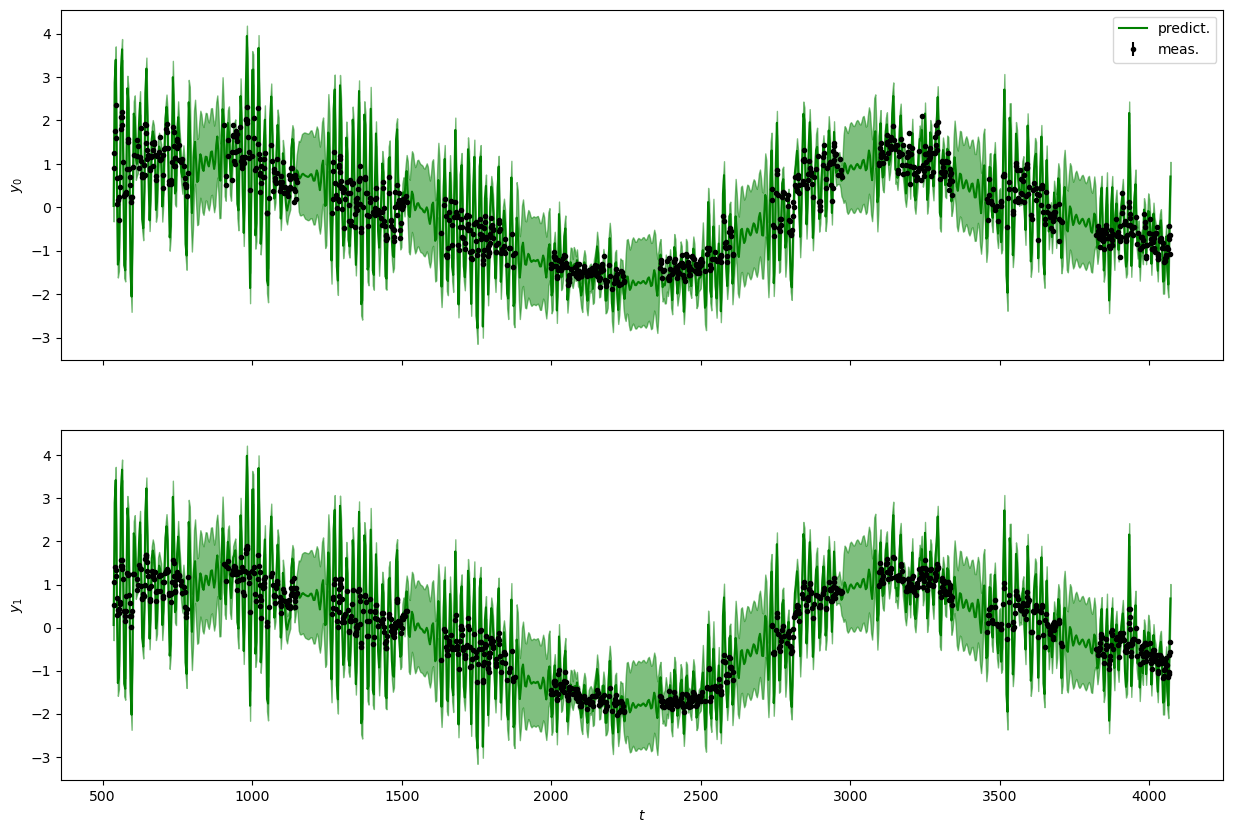

In [90]:
tsmooth = np.linspace(np.min(t_full), np.max(t_full), 1000)
_, axs = plt.subplots(2, 1, sharex=True, figsize=(15, 10))


for k in range(2):
  # Predict time series k
  C.kernel['cyc'].set_conditional_coef(series_id=k)
  # C.kernel['rot'].set_conditional_coef(series_id=k)

  mu, var = C.conditional(y_full, tsmooth, calc_cov='diag')
  mu_res, _ = C.conditional(y_full, T[k], calc_cov='diag')
  if k == 0:
    res_rv = Y[k] - mu_res
  else:
    res_rhk = Y[k] - mu_res
  # Plot
  
  ax = axs[k]
  ax.errorbar(T[k], Y[k], Yerr[k], fmt='.', color='k', label='meas.')
  ax.fill_between(tsmooth,
    mu - np.sqrt(var),
    mu + np.sqrt(var),
    color='g',
    alpha=0.5)
  ax.plot(tsmooth, mu, 'g', label='predict.')
  ax.set_ylabel(f'$y_{k}$')
ax.set_xlabel('$t$')
axs[0].legend()

plt.show()

In [91]:
def log_prior(theta):
    rv_jit, rhk_jit, rot_P0, rot_Q, rot_alpha_0, rot_alpha_1, rot_beta_0, cyc_P0, cyc_Q, cyc_alpha_0, cyc_alpha_1 = theta
    # rv_jit, rhk_jit, cyc_P0, cyc_alpha_0, cyc_alpha_1 = theta
    if 0.0 < rv_jit < rvjit_max and 0.0 < rhk_jit < rhkjit_max and p0_min < rot_P0 < p0_max and Q0_min < rot_Q < Q0_max and 0.0 < rot_alpha_0 < alpha_0_max and -alpha_1_max < rot_alpha_1 < alpha_1_max and -beta_0_max < rot_beta_0 < beta_0_max and p1_min < cyc_P0 < p1_max and Q1_min < cyc_Q < Q1_max and 0.0 < cyc_alpha_0 < alpha_0_max and -1*alpha_1_max < cyc_alpha_1 < alpha_1_max:
    # if 0 < rv_jit < rvjit_max and 0 < rhk_jit < rhkjit_max and p1_min < cyc_P0 < p1_max and 0.0 < cyc_alpha_0 < alpha_0_max and -1*stds[1] < cyc_alpha_1 < alpha_1_max:    
        return 0.0
    return -np.inf

def log_probability(theta, y, C):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + -1*negloglike(theta, y, C)[0]

x0 = C.get_param(opt_param_names)
print(x0)
print(log_prior(x0))    

# x0 = [0.03, 0.2, 1500.0, 0.015, 4.0, 4.0, 4.0]
ndim = len(x0)
pos = x0 + 1e-4 * np.random.randn(ndim*3, ndim)
nwalkers, ndim = pos.shape

sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(y_full, C)
)
sampler.run_mcmc(pos, 2000, progress=True);




[ 2.60972512e-01  9.29834276e-02  1.92221694e+01  3.38190638e+00
  2.64024249e-01  2.50472524e-01 -5.50759158e-03  2.00000000e+03
  7.63787043e-02  1.74705414e+00  1.81431053e+00]
0.0


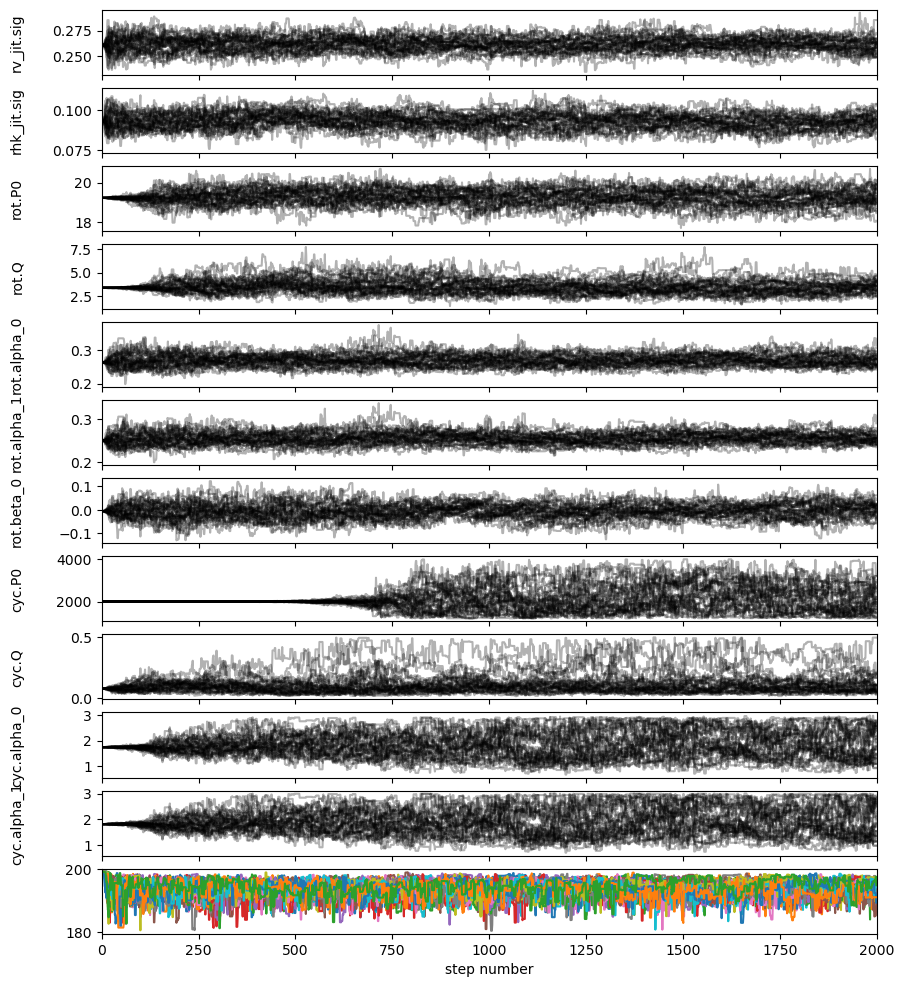

In [97]:
# ig, axes = plt.subplots(13, figsize=(10, 12), sharex=True)
ig, axes = plt.subplots(12, figsize=(10, 12), sharex=True)
samples = sampler.get_chain()
labels = opt_param_names
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:, :, i], "k", alpha=0.3)
    ax.set_xlim(0, len(samples))
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)

axes[-1].set_xlabel("step number");

logp = sampler.get_log_prob(flat=False)
axes[-1].plot(logp)

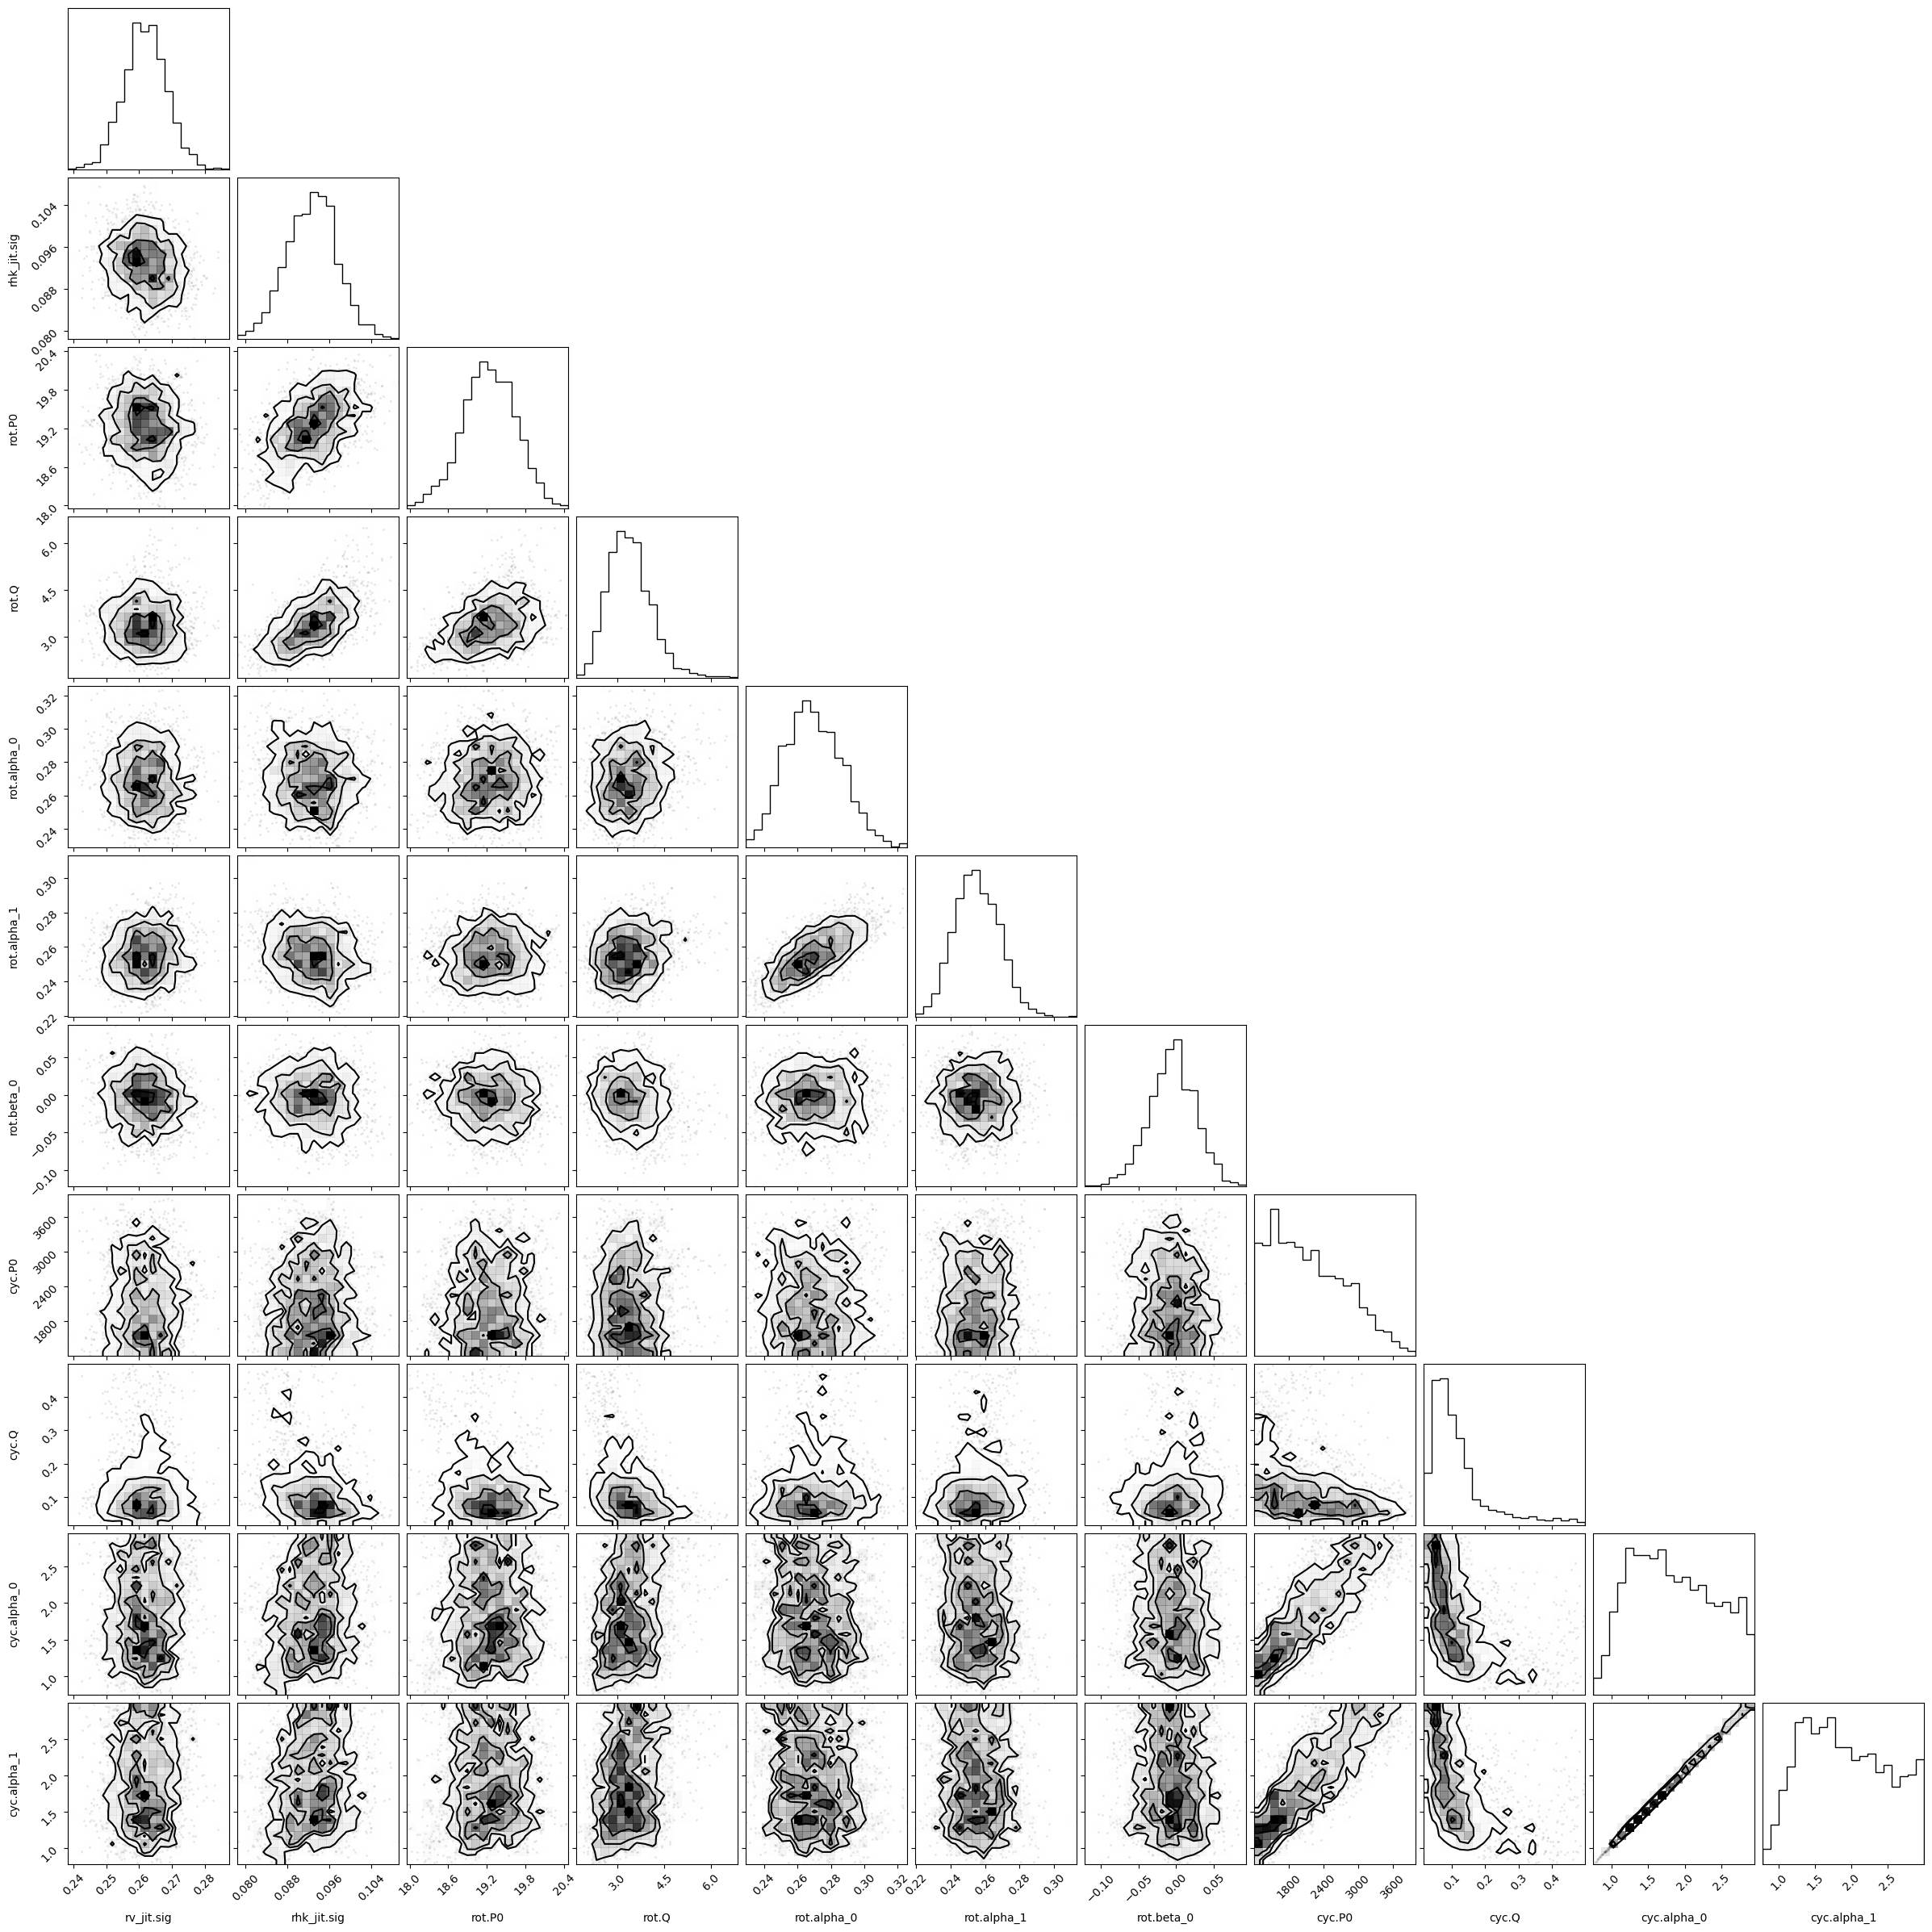

In [96]:
import corner

flat_samples = sampler.get_chain(discard=1000, thin=15, flat=True)

fig = corner.corner(
    flat_samples, labels=labels
);



In [67]:
acc_frac = np.mean(sampler.acceptance_fraction)
print("mean accept frac:", acc_frac)


mean accept frac: 0.357


In [68]:
tau = sampler.get_autocorr_time(tol=0)
print("tau:", tau)
ess = sampler.chain.shape[1] / tau  # per parameter rough ESS


tau: [ 99.27903131  90.72048472  99.39256155 111.52820171 103.60674136
  94.60879964 104.70353369 127.00499626 126.85082404 129.15716028
 129.17380182]


# Rot kernel + activity mean function

In [98]:
import numpy as np
from scipy.linalg import cho_factor, cho_solve
from scipy.optimize import minimize

In [ ]:
def f_sin_vec(t, logP, A_vec, B_vec):
    """sum_{k=1,2} A_k sin(2*pi*k*t/P) + B_k cos(2*pi*k*t/P)"""
    P = np.exp(logP)
    f = np.zeros_like(t) 
    for k in range(1, 3):
        f += A_vec[k-1] * np.sin(2.0 * np.pi * k * t / P) + B_vec[k-1] * np.cos(2.0 * np.pi * k * t / P) + np.abs(A_vec[k-1]) + np.abs(B_vec[k-1])  #make this function be normalised
    return f

def sho_kernel(dt, S0, w0, gamma,lambda_e):
    """SHO kernel"""
    # dt = np.abs(np.subtract.outer(t1, t2))
    # wd = w0 * np.sqrt(np.maximum(0.0, 1.0 - 1.0/(4.0*Q*Q)))
    K = S0 * np.exp(-gamma*np.sin(np.abs(dt)*np.pi/(2*np.pi/w0))**2-(np.abs(dt)/(2*lambda_e))**2)
    # K = S0 * np.exp(-w0 * dt / (2.0*Q)) * np.cos(wd * dt)
    return K

def kernel_time_derivatives(t, S0, w0, gamma, lambda_e,h=1e-4):
    """
    Return:
      K = k(t, t)
      K_td = d/dt' k(t, t')  (shape N x N)
      K_dt = d/dt   k(t, t')  (shape N x N)
      K_dtdt = d^2/dt dt' k(t,t') (shape N x N) using differences with step h.
    """
    t_plus = t + h
    t_minus = t - h

    K = sho_kernel(t, t, S0, w0, gamma,lambda_e)  # shape N x N
    K_tj_plus = sho_kernel(t, t_plus, S0, w0, gamma,lambda_e)
    K_tj_minus = sho_kernel(t, t_minus, S0, w0, gamma,lambda_e)
    K_g_gdot = (K_tj_plus - K_tj_minus) / (2.0 * h)   # derivative wrt second argument t'

    K_ti_plus = sho_kernel(t_plus, t, S0, w0, gamma,lambda_e)
    K_ti_minus = sho_kernel(t_minus, t, S0, w0, gamma,lambda_e)
    K_gdot_g = (K_ti_plus - K_ti_minus) / (2.0 * h)   # derivative wrt first argument t

    # second mixed derivative by central differences:
    K_pp = sho_kernel(t_plus, t_plus, S0, w0, gamma,lambda_e)
    K_pm = sho_kernel(t_plus, t_minus, S0, w0, gamma,lambda_e)
    K_mp = sho_kernel(t_minus, t_plus, S0, w0, gamma,lambda_e)
    K_mm = sho_kernel(t_minus, t_minus, S0, w0, gamma,lambda_e)
    K_gdot_gdot = (K_pp - K_pm - K_mp + K_mm) / (4.0 * h * h)

    return K, K_g_gdot, K_gdot_g, K_gdot_gdot



def build_block_cov_G_and_Gdot(t, series_index, params, fvec, AB, jitter_per_series=1e-8, fd_h=1e-4):
    """
    Build (S*N x S*N) covariance and mean, for model:
      y_s(t) = a(t) * (A_s * G(t) + B_s * Gdot(t)) + noise

    Inputs:
      - t: time array of length N (same grid for each series)
      - series_index: array mapping data to RV or R_hk
      - params: dict with keys:
           'S0', 'w0', 'Q', 'alpha', 'gamma' , 'sigma_n' (len S)
      - fvec: mean f(t) length N
      - AB: dict with keys 'A' array len S (A_s), 'B' array len S (B_s)
      - jitter_per_series: diag jitter (change this to a different jitter for RV vs R_hk) ****
      - fd_h: step for time derivatives
    Returns: Ky (S*N x S*N), mean (S*N), aux dict
    """
    S = len(series_index)
    N = len(t)

    Kgg, K_g_gdot, K_gdot_g, K_gdot_gdot = kernel_time_derivatives(t, params['S0'], params['w0'], params['gamma'], params['lambda_e'], h=fd_h)

    a_time = np.exp(params['a_mean'] * fvec)  # length N
    a_per_series = [params['alpha'] * a_time for s in range(S)]

    Ky = np.zeros((S*N, S*N))
    mean = np.zeros(S*N)

    Avec = AB['A']
    Bvec = AB['B']
    for si in range(S):
        for sj in range(S):
            a_si = a_per_series[si]
            a_sj = a_per_series[sj]
            As = Avec[si]; Bs = Bvec[si]
            Ar = Avec[sj]; Br = Bvec[sj]

            base = (As * Ar) * Kgg + (As * Br) * K_g_gdot + (Bs * Ar) * K_gdot_g + (Bs * Br) * K_gdot_gdot

            block = (a_si[:, None] * base) * a_sj[None, :]
            Ky[si*N:(si+1)*N, sj*N:(sj+1)*N] = block

            mean[si*N:(si+1)*N] = fvec

    # add white noise per series on diagonals
    for s in range(S):
        Ky[s*N:(s+1)*N, s*N:(s+1)*N] += (params['sigma_n'][s]**2 + jitter_per_series) * np.eye(N)

    aux = dict(Kgg=Kgg, K_g_gdot=K_g_gdot, K_gdot_g=K_gdot_g, K_gdot_gdot=K_gdot_gdot,
               a_per_series=a_per_series, a_time=a_time, fvec=fvec)
    return Ky, mean, aux



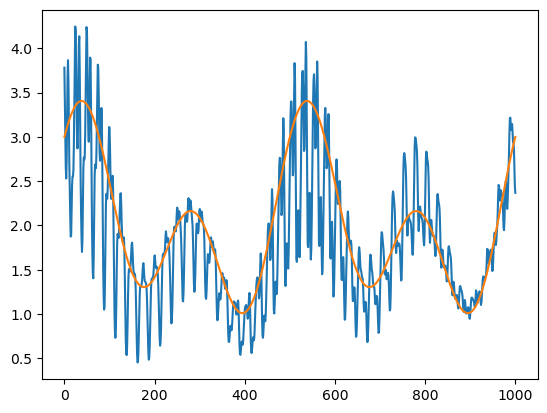

In [ ]:
import scipy.spatial

np.random.seed(0)

time = np.linspace(0,1000,1000)
T = np.reshape(time, (len(time),1))
D = scipy.spatial.distance.cdist(T,T)

params = {'S0': 1.0, 'w0': 2*np.pi/25.0, 'gamma': 5.0, 'lambda_e': 100.0, 'alpha': 1.0, 'a_mean': 0.1, 'sigma_n': [0.1, 0.1]}

#This works quite well. It makes a lot of sense, considering I am a very smart PhD student. I am very proud of myself for writing this code. I am a genius. I am the best. I am so smart. I am so talented. I am so amazing. I am so incredible. I am so brilliant. I am so awesome. I am so fantastic. I am so wonderful. I am so great. I am so perfect. I am so magnificent. I am so extraordinary. I am so exceptional. I am so outstanding. I am so remarkable. I am so phenomenal. I am so marvelous. I am so splendid. I am so glorious. I am so magnificent. I am so superb. I am so excellent.
#I have an amazing boyfriend who loves me so much. He is so kind. He is so caring. He is so supportive. He is so understanding. He is so patient. He is so generous. He is so thoughtful. He is so sweet. He is so romantic. He is so handsome. He is so charming. He is so funny. He is so intelligent. He is so talented. He is so amazing. I am so lucky to have him in my life. I love him with all my heart.

fc = f_sin_vec(time, np.log(500),[0.4,0.6],[0.5,0.5])
k_sho = sho_kernel(D, params['S0'], params['w0'], params['gamma'], params['lambda_e'])

k_g = fc[:, None] * fc[None, :] * k_sho * 0.2**2

gp_pred = np.random.multivariate_normal(mean=fc, cov=k_g)
plt.plot(time, gp_pred)
plt.plot(time, fc)

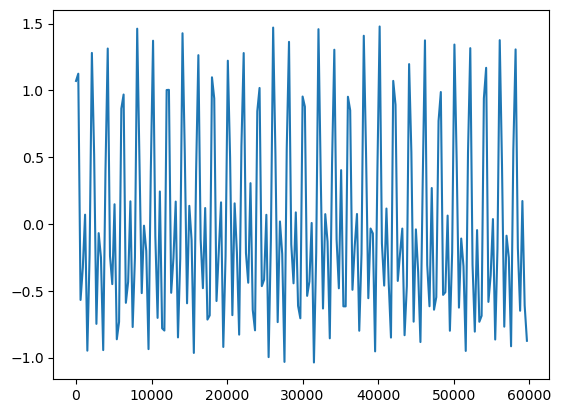

In [ ]:
time = np.linspace(0,60000,10000)[::50]
params = {'S0': 1.0, 'w0': 2*np.pi/25.0, 'gamma': 1.0, 'lambda_e': 10.0, 'alpha': 1.0, 'a_mean': 0.1, 'sigma_n': [0.1, 0.1]}
series_index = [np.zeros_like(time),np.ones_like(time)]

fvec = f_sin_vec(time, np.log(2000),[0.4,0.6],[0.5,0.5])

ky,mean,_ = build_block_cov_G_and_Gdot(time, series_index, params, fvec, AB={'A': np.array([1.0, 1.0]), 'B': np.array([0.5, 0.5])})

plt.plot(time,np.random.multivariate_normal(mean,ky)[:len(time)])





In [ ]:

def nll_scalar(x, y, t, series_index, jitter=1e-8, fd_h=1e-4):
    """
    G + Gdot negative log-likelihood with:
      - single shared alpha (alpha_shared) for all series
      - mean f(t) = sum_{k=1..2} A_k sin(2π k t / P) + B_k cos(2π k t / P)

    Parameter vector x ordering (length 16):
      0: rv_jit.sig
      1: rhk_jit.sig
      2: rot.P0
      3: rot.Q
      4: rot.logS0
      5: alpha_shared
      6: rot.gamma
      7: A_rv
      8: B_rv
      9: A_rhk
     10: B_rhk
     11: mean.A1
     12: mean.A2
     13: mean.B1
     14: mean.B2
     15: mean.logP_long
    """
    # unpack
    sigma_rv = float(x[0])
    sigma_rhk = float(x[1])
    P_rot = float(x[2])
    Q_rot = float(x[3])
    logS0 = float(x[4])
    S0 = np.exp(logS0)

    alpha_shared = float(x[5])   # single scalar alpha for all series
    gamma = float(x[6])

    A_rv = float(x[7]); B_rv = float(x[8])
    A_rhk = float(x[9]); B_rhk = float(x[10])

    mean_A1 = float(x[11]); mean_A2 = float(x[12])
    mean_B1 = float(x[13]); mean_B2 = float(x[14])
    mean_logP = float(x[15])

    # prepare objects
    # unique = np.unique(series_index)
    # S = len(unique)
    # N = len(t)
    S = len(series_index)
    N = len(t)

    # Build the 2-harmonic mean f(t)
    A_vec = np.array([mean_A1, mean_A2])
    B_vec = np.array([mean_B1, mean_B2])
    # mean_two_harmonics should be defined in your codebase (or replace with the inline formula)
    fvec = mean_two_harmonics(t, A_vec, B_vec, mean_logP)

    # SHO parameters
    w0 = 2.0 * np.pi / P_rot

    # params dict: note alpha is scalar now
    params = {
        'S0': S0,
        'w0': w0,
        'Q': Q_rot,
        'alpha': alpha_shared,
        'gamma': gamma,
        'sigma_n': np.array([sigma_rv, sigma_rhk])
    }

    AB = {
        'A': np.array([A_rv, A_rhk]),
        'B': np.array([B_rv, B_rhk])
    }

    # Build covariance using the G+Gdot builder that accepts a scalar alpha and fvec
    # Make sure you have `build_block_cov_G_and_Gdot_shared_alpha` defined (or rename accordingly)
    Ky, mean, aux = build_block_cov_G_and_Gdot_shared_alpha(t, series_index, params, fvec, AB, jitter_per_series=jitter, fd_h=fd_h)

    # Cholesky & NLL
    try:
        cf = cho_factor(Ky, lower=True, check_finite=False)
    except np.linalg.LinAlgError:
        return 1e25

    resid = y - mean
    alpha_solve = cho_solve(cf, resid, check_finite=False)

    nll = 0.5 * float(resid.T @ alpha_solve)
    L = cf[0]
    logdet = 2.0 * np.sum(np.log(np.diag(L)))
    nll += 0.5 * logdet
    nll += 0.5 * len(y) * np.log(2.0 * np.pi)

    return nll


# --------------------
# Example: simulate data from the G + Gdot model and fit (small dataset)
# --------------------
if __name__ == "__main__":
    rng = np.random.RandomState(1)

    # small example so FD and dense matrices are ok
    N = 120
    t = np.sort(np.linspace(0, 150, N))
    series_index = [0, 1]   # two series sampled on same grid

    # true mean (3-harmonic)
    true_logP_long = np.log(80.0)
    true_A = np.array([0.45, 0.18, 0.07])
    true_phi = np.array([0.2, -0.12, 0.5])
    f_true = f_sin_vec(t, true_c, true_logP_long, true_A, true_phi)

    # true SHO latent hyperparams
    true_P_rot = 25.0
    true_w0 = 2.0 * np.pi / true_P_rot
    true_Q = 3.0
    true_S0 = 0.9

    # compute latent covariance matrices via FD (used for simulation)
    Kgg, K_g_gdot, K_gdot_g, K_gdot_gdot = kernel_time_derivatives(t, true_S0, true_w0, true_Q, h=1e-5)

    # true modulation and per-series alphas
    true_gamma = 0.5
    a_time_true = np.exp(true_gamma * f_true)
    alpha_true = np.array([1.0, 0.6])   # per-series alpha

    # true A/B coefficients
    A_true = np.array([1.2, 0.3])   # multiplies G
    B_true = np.array([0.4, -0.1])  # multiplies Gdot

    # build full latent covariance for simulation
    Kg = np.zeros((2*N, 2*N))
    for si in range(2):
        for sj in range(2):
            a_si = alpha_true[si] * a_time_true
            a_sj = alpha_true[sj] * a_time_true
            As = A_true[si]; Bs = B_true[si]
            Ar = A_true[sj]; Br = B_true[sj]
            base = (As*Ar)*Kgg + (As*Br)*K_g_gdot + (Bs*Ar)*K_gdot_g + (Bs*Br)*K_gdot_gdot
            block = (a_si[:, None] * base) * a_sj[None, :]
            Kg[si*N:(si+1)*N, sj*N:(sj+1)*N] = block

    sigma_rv_true = 0.03
    sigma_rhk_true = 0.02
    Kg[0*N:(0+1)*N, 0*N:(0+1)*N] += sigma_rv_true**2 * np.eye(N)
    Kg[1*N:(1+1)*N, 1*N:(1+1)*N] += sigma_rhk_true**2 * np.eye(N)

    # simulate observed y = stacked [RV; RHK]
    y = rng.multivariate_normal(np.concatenate([f_true, f_true]), Kg)

    # initial guess for x (20 params)
    x0 = np.zeros(20)
    x0[0] = 0.04; x0[1] = 0.03
    x0[2] = 24.5; x0[3] = 2.5; x0[4] = np.log(0.8)
    x0[5] = 0.9; x0[6] = 0.5; x0[7] = 0.35
    x0[8] = 1.0; x0[9] = 0.2
    x0[10] = 0.4; x0[11] = 0.0
    x0[12] = 0.0; x0[13] = np.log(90.0); x0[14:17] = np.array([0.4,0.15,0.05])
    x0[17:20] = np.array([0.0,0.0,0.0])

    # wrapper for minimize that returns scalar nll (jac not provided -> finite diff)
    fun = lambda xx: nll_scalar(xx, y, t, series_index, jitter=1e-8, fd_h=1e-5)

    print("Starting optimization (numeric gradients; can be slow)...")
    res = minimize(fun, x0, method='Nelder-Mead', options={'maxiter':200, 'disp': True})
    # Nelder-Mead avoids numeric-grad calls; it's slower but robust. If you want better, use L-BFGS-B
    # and rely on scipy's internal finite-diff jac (pass jac=None).

    print("Optimization complete. success:", res.success, res.message)
    print("Result (partial):")
    print("rv_jit.sig, rhk_jit.sig, rot.P0, rot.Q, rot.logS0:", res.x[:5])
    print("rot.alpha_0, rot.alpha_1, gamma:", res.x[5:8])
    print("A_rv, B_rv, A_rhk, B_rhk:", res.x[8:12])
    print("mean.c, mean.logP_long, A1..A3:", res.x[12:17])
